# Ridge sizing audit — signal-only inference

This diagnostic is retained as `asset_vol.ipynb` for continuity with the requested filename. **It does not use asset-return volatility.** `takehome.ipynb` is the submission notebook and owns the final fit/export. The obsolete `02_normalization.ipynb` and `takehome_asset_vol.ipynb` have been removed after integrating their relevant signal-only controls.

Use the same dszl(10) inputs, fixed Ridge configuration, two-year windows and lagged signal-only sizing. Reproduce the old **Original shape** reference and report concentration as well as peak units. All visible strategy curves below are explicitly bounded before multiplying by returns; there is no P&L clipping, hidden rescaling or held-out scoring. The audit does not write submission forecasts.


In [1]:
from pathlib import Path
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
get_ipython().run_line_magic('matplotlib','inline')
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src'/'takehome').exists())
sys.path.insert(0,str(ROOT/'src'))
from takehome.data import training_data, read_parquet_window
from takehome.features import with_cashflow_feature, dszl_design, ts_std, sharpe
from takehome.fitters import BatchRidge, BatchLasso, calendar_walk_forward_folds, walk_forward_sweep
from takehome.normalization import signal_weights
DATA_PATH = Path(os.environ.get('DATA_PATH', ROOT/'ESc1_signal_components_5min (6).parquet'))
HL, DSZL_HL, WINDOW_YEARS, BATCH_SIZE = 6048, 10, 2, 8
SIGNAL_RULE = dict(method='std', floor_fraction=.25, cap=3., lag=1)
RIDGE_CONFIG = dict(alpha=.01, decay=2**(-1/HL), fit_intercept=True)
RIDGE_ALPHA = RIDGE_CONFIG['alpha']
RIDGE_ALPHAS = np.logspace(-6,2,9)
labels=read_parquet_window(DATA_PATH,columns=['ret_5m'])
_,split=training_data(labels);del labels
df=with_cashflow_feature(read_parquet_window(DATA_PATH,start=split['first_label'],stop=split['cutoff']))
x_cols=[c for c in df if c.startswith('x') and c[1:].isdigit()]
model_X=dszl_design(df[x_cols],hl=DSZL_HL,batch_size=BATCH_SIZE)
X=model_X.to_numpy(copy=False); y=df.ret_5m.to_numpy(); W=np.isfinite(y).astype(float)
folds=calendar_walk_forward_folds(df.index,train_years=WINDOW_YEARS,test_years=WINDOW_YEARS)
OOS_FIRST=folds[0]['predict_start']; SCORE_FIRST=OOS_FIRST+HL
rows=np.arange(len(df))
def oos_series(values):
    return pd.Series(values,index=df.index).where(rows>=OOS_FIRST)
print('Research rows / dszl columns:',len(df),len(x_cols));display(pd.DataFrame(folds))


Research rows / dszl columns: 640734 100


,train_start,train_stop,predict_start,predict_stop,train_start_time,train_stop_time,predict_start_time,predict_stop_time
0,0,150191,150191,300384,2014-01-02 06:05:00-05:00,2016-01-02 06:05:00-05:00,2016-01-02 06:05:00-05:00,2018-01-02 06:05:00-05:00
1,150191,300384,300384,450720,2016-01-02 06:05:00-05:00,2018-01-02 06:05:00-05:00,2018-01-02 06:05:00-05:00,2020-01-02 06:05:00-05:00
2,300384,450720,450720,600911,2018-01-02 06:05:00-05:00,2020-01-02 06:05:00-05:00,2020-01-02 06:05:00-05:00,2022-01-02 06:05:00-05:00
3,450720,600911,600911,640734,2020-01-02 06:05:00-05:00,2022-01-02 06:05:00-05:00,2022-01-02 06:05:00-05:00,2024-01-02 06:05:00-05:00


## Identical forecasts, different position rules

The raw-unit legacy denominator and past-anchored Original shape are controls, not fixes. The latter must have the same jump concentration as the former on matched rows. Lagging a scale changes timing; a floor limits collapse; only the cap guarantees a bound against an arbitrary new numerator. The same frozen Ridge paths are passed to every rule.

<span style="color:red">TODO — Ridge sizing: test a properly defined forecast t-stat instead of yhat/ewm_std(yhat); temporal forecast volatility is not forecast standard error.</span>
<span style="color:red">TODO — Fitting: assess weighting by volume as a proxy for feasible traded size; these models still use unit label weights.</span>


In [2]:
models = {f'Ridge {a:g}': BatchRidge(len(x_cols), **(RIDGE_CONFIG | {'alpha':float(a)})) for a in RIDGE_ALPHAS}
models['Lasso 1e-05'] = BatchLasso(len(x_cols),RIDGE_CONFIG['decay'],1e-5,fit_intercept=True,tol=1e-11)
batch_paths=walk_forward_sweep(models,X,y,W=W,folds=folds)


,observations,max_abs_weight,p99_abs_weight,max_abs_bar_pnl,max_abs_day_pnl,max_abs_day_over_daily_std,top10_abs_pnl_share,daily_mean_over_std,capped_percent
rule,,,,,,,,,
Legacy raw units,446236,562072.523267,149511.152507,2607.489235,4388.353336,10.153105,0.408759,0.036708,0.000000
Original shape,446236,29.426460,7.827431,0.136511,0.229746,10.153105,0.408759,0.036708,0.000000
Prior variance,446236,29.735754,7.838676,0.137048,0.230823,10.179826,0.410363,0.036684,0.000000
Floored variance + cap,446236,3.000000,3.000000,0.068923,0.119142,8.590458,0.283942,0.049193,8.498642
Std + floor + cap,446236,3.000000,3.000000,0.059682,0.116651,10.471400,0.372805,0.045334,2.594591
RMS + floor + cap,446236,3.000000,3.000000,0.059682,0.115648,10.433614,0.373665,0.045453,2.546859


DEFAULT_RIDGE_SIZING
                        observations  max_abs_weight  p99_abs_weight  max_abs_bar_pnl  max_abs_day_pnl  max_abs_day_over_daily_std  top10_abs_pnl_share  daily_mean_over_std  capped_percent
rule                                                                                                                                                                                        
Legacy raw units              446236   562072.523267   149511.152507      2607.489235      4388.353336                   10.153105             0.408759             0.036708        0.000000
Original shape                446236       29.426460        7.827431         0.136511         0.229746                   10.153105             0.408759             0.036708        0.000000
Prior variance                446236       29.735754        7.838676         0.137048         0.230823                   10.179826             0.410363             0.036684        0.000000
Floored variance + cap        4462

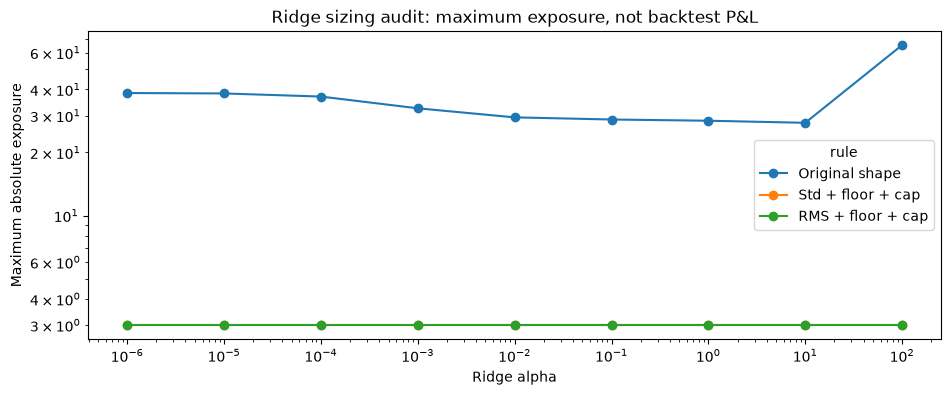

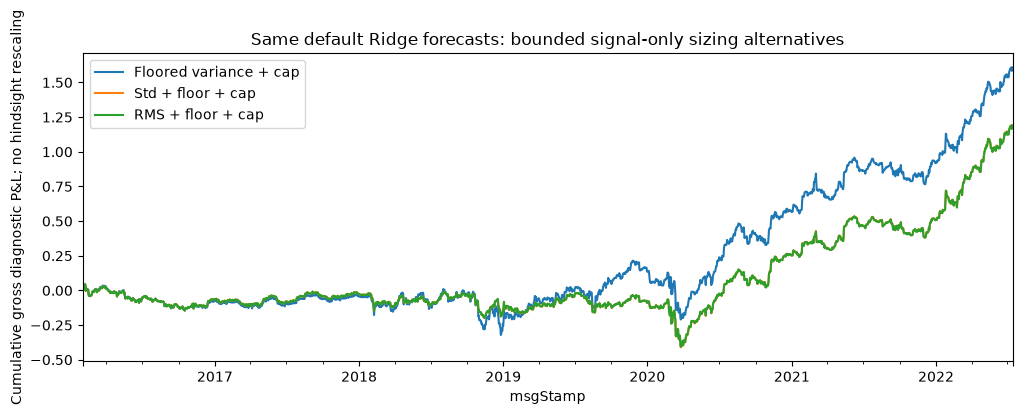

Only an explicit exposure bound guarantees control against arbitrary new signal outliers.


In [3]:
SIZING_RULES = {
    'Legacy raw units': None,
    'Original shape': dict(method='variance', floor_fraction=0, cap=None, lag=0),
    'Prior variance': dict(method='variance', floor_fraction=0, cap=None, lag=1),
    'Floored variance + cap': dict(method='variance', floor_fraction=.25, cap=3., lag=1),
    'Std + floor + cap': SIGNAL_RULE,
    'RMS + floor + cap': dict(method='rms', floor_fraction=.25, cap=3., lag=1),
}

def compare_sizing(prediction, returns, first_row):
    positions = pd.DataFrame({name: (prediction.div(ts_std(prediction, HL).pow(2))
        if rule is None else signal_weights(prediction, HL, **rule))
        for name, rule in SIZING_RULES.items()})
    common = positions.notna().all(axis=1) & np.isfinite(returns) & (np.arange(len(returns)) >= first_row)
    positions = positions.where(common, axis=0)
    contributions = positions.mul(returns, axis=0)
    daily = contributions.resample('D').sum().loc[returns.index[first_row].normalize():]
    records = []
    for name in positions:
        w = positions[name].dropna().abs(); p = contributions[name].dropna()
        total = p.abs().sum(); sigma = daily[name].std()
        records.append(dict(rule=name, observations=len(w), max_abs_weight=w.max(),
            p99_abs_weight=w.quantile(.99), max_abs_bar_pnl=p.abs().max(),
            max_abs_day_pnl=daily[name].abs().max(),
            max_abs_day_over_daily_std=daily[name].abs().max()/sigma if sigma > 0 else np.nan,
            top10_abs_pnl_share=100*p.abs().nlargest(10).sum()/total if total > 0 else np.nan,
            daily_mean_over_std=sharpe(daily[name]),
            capped_percent=100*w.ge(3.-1e-12).mean() if SIZING_RULES[name] is not None and SIZING_RULES[name].get('cap') is not None else 0.))
    return pd.DataFrame(records).set_index('rule'), positions, contributions, daily

sizing_tables, selected_sizing_daily = [], None
for a in RIDGE_ALPHAS:
    prediction = oos_series(batch_paths[f'Ridge {a:g}'].prediction_)
    stats, positions, contributions, daily = compare_sizing(prediction, df.ret_5m, SCORE_FIRST)
    sizing_tables.append(stats.assign(alpha=a))
    for name, rule in SIZING_RULES.items():
        if rule is not None and rule.get('cap') is not None:
            assert positions[name].abs().max() <= rule['cap']
            assert ((contributions[name].abs() <= rule['cap'] * df.ret_5m.abs()) | contributions[name].isna()).all()
    if a == RIDGE_ALPHA:
        ridge_sizing = stats
        selected_sizing_daily = daily
        display(stats)
        print('DEFAULT_RIDGE_SIZING'); print(stats.to_string())
all_ridge_sizing = pd.concat(sizing_tables).reset_index().set_index(['alpha','rule'])
all_ridge_sizing.max_abs_weight.unstack('rule')[['Original shape','Std + floor + cap','RMS + floor + cap']].plot(
    logx=True, logy=True, marker='o', figsize=(11,4), title='Ridge sizing audit: maximum exposure, not backtest P&L')
plt.xlabel('Ridge alpha'); plt.ylabel('Maximum absolute exposure'); plt.show(); plt.close('all')
selected_sizing_daily[['Floored variance + cap','Std + floor + cap','RMS + floor + cap']].cumsum().plot(
    figsize=(12,4), title='Same default Ridge forecasts: bounded signal-only sizing alternatives')
plt.ylabel('Cumulative gross diagnostic P&L; no hindsight rescaling'); plt.show(); plt.close('all')
print('Only an explicit exposure bound guarantees control against arbitrary new signal outliers.')


## Selected configuration, and a two-year label-blackout simulation

The first chart uses the same Ridge and sizing settings as the final validation plot in `takehome.ipynb`. The simulation then fits only the two years preceding the final two years **within research**, freezes the coefficients for that entire block and warms the signal normalizer using only its chronological forecast history. The exposure scale sees signals, never future returns. This does not access the assignment's withheld interval.


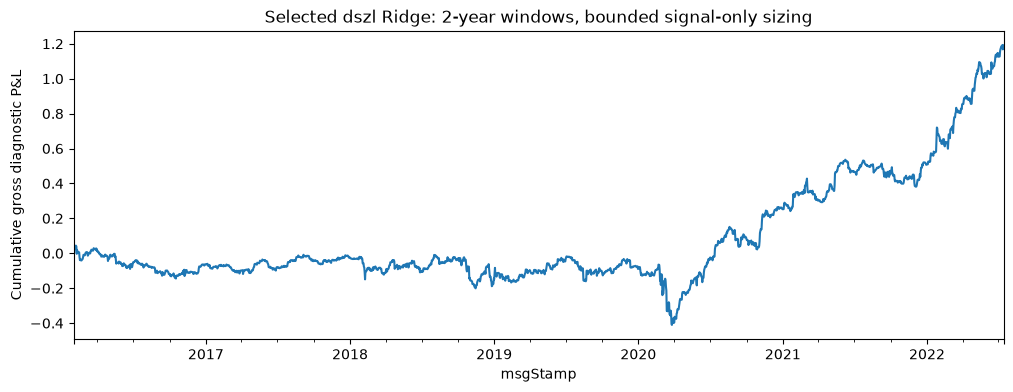

SELECTED_RIDGE_VALIDATION {'daily_mean_over_std': np.float64(0.0453342423308056), 'max_abs_weight': np.float64(3.0), 'observations': 446236}


,observations,max_abs_weight,p99_abs_weight,max_abs_bar_pnl,max_abs_day_pnl,max_abs_day_over_daily_std,top10_abs_pnl_share,daily_mean_over_std,capped_percent
rule,,,,,,,,,
Legacy raw units,139507,602722.702882,48957.554174,1261.354441,1721.603473,9.500316,1.181282,0.043468,0.000000
Original shape,139507,31.554639,2.563099,0.066036,0.090132,9.500316,1.181282,0.043468,0.000000
Prior variance,139507,32.904678,2.567255,0.068192,0.091149,9.580539,1.198332,0.043389,0.000000
Floored variance + cap,139507,3.000000,2.567255,0.028825,0.045551,5.285384,0.560466,0.040411,0.688138
Std + floor + cap,139507,3.000000,3.000000,0.028825,0.079536,5.796031,0.423540,0.052880,2.986230
RMS + floor + cap,139507,3.000000,3.000000,0.028825,0.079200,5.801215,0.423728,0.052743,2.952540


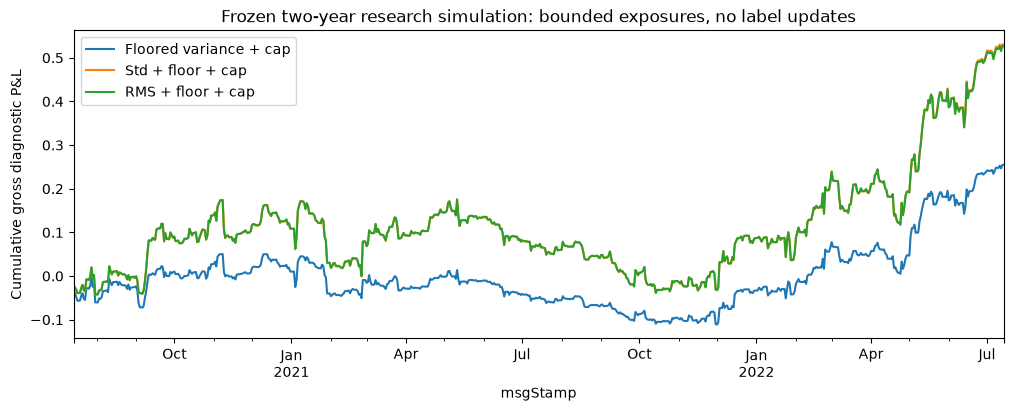

BLACKOUT_SIMULATION
                        observations  max_abs_weight  p99_abs_weight  max_abs_bar_pnl  max_abs_day_pnl  max_abs_day_over_daily_std  top10_abs_pnl_share  daily_mean_over_std  capped_percent
rule                                                                                                                                                                                        
Legacy raw units              139507   602722.702882    48957.554174      1261.354441      1721.603473                    9.500316             1.181282             0.043468        0.000000
Original shape                139507       31.554639        2.563099         0.066036         0.090132                    9.500316             1.181282             0.043468        0.000000
Prior variance                139507       32.904678        2.567255         0.068192         0.091149                    9.580539             1.198332             0.043389        0.000000
Floored variance + cap        13950

In [4]:
selected=oos_series(batch_paths[f'Ridge {RIDGE_ALPHA:g}'].prediction_)
w=signal_weights(selected,HL,**SIGNAL_RULE).where(rows>=SCORE_FIRST)
pnl=w*df.ret_5m
daily=pnl.resample('D').sum().loc[df.index[SCORE_FIRST].normalize():]
daily.cumsum().plot(figsize=(12,4),title='Selected dszl Ridge: 2-year windows, bounded signal-only sizing')
plt.ylabel('Cumulative gross diagnostic P&L');plt.show();plt.close('all')
print('SELECTED_RIDGE_VALIDATION',dict(daily_mean_over_std=sharpe(daily),max_abs_weight=w.abs().max(),observations=int(pnl.count())))

freeze_date=df.index[-1]-pd.DateOffset(years=WINDOW_YEARS)
freeze_train_date=freeze_date-pd.DateOffset(years=WINDOW_YEARS)
a=int(df.index.searchsorted(freeze_train_date)); b=int(df.index.searchsorted(freeze_date))
blackout_model=BatchRidge(len(x_cols),**RIDGE_CONFIG).fit(X[a:b],y[a:b],W=W[a:b])
blackout_prediction=selected.copy()
blackout_prediction.iloc[b:]=blackout_model.predict(X[b:])
blackout_stats,blackout_w,blackout_pnl,blackout_daily=compare_sizing(blackout_prediction,df.ret_5m,b)
display(blackout_stats)
blackout_daily[['Floored variance + cap','Std + floor + cap','RMS + floor + cap']].cumsum().plot(
    figsize=(12,4),title='Frozen two-year research simulation: bounded exposures, no label updates')
plt.ylabel('Cumulative gross diagnostic P&L');plt.show();plt.close('all')
assert blackout_w['Std + floor + cap'].abs().max()<=3
print('BLACKOUT_SIMULATION');print(blackout_stats.to_string())


## Collapse, missing observations and an unseen outlier

The stress path tests the numerical issue directly, without fitting anything to market returns. A nearly constant nonzero signal is followed by zero/missing stretches and a new outlier. Bounded exposures preserve signal direction and prefix causality. A cap is not a promise of alpha or a bound on the asset's own returns.


In [5]:
rng=np.random.default_rng(41)
z=pd.Series(rng.normal(size=3000),index=pd.date_range('2000',periods=3000,freq='5min'))
z.iloc[150:2400]=.001;z.iloc[2400:2500]=0;z.iloc[2600:2700]=np.nan;z.iloc[2900]=1e6
stress={name:signal_weights(z,20,**rule).abs().max() for name,rule in SIZING_RULES.items() if rule is not None}
display(pd.Series(stress,name='maximum_absolute_exposure').to_frame())
for name in ['Floored variance + cap','Std + floor + cap','RMS + floor + cap']:
    assert stress[name]<=3
prefix=signal_weights(z.iloc[:2000],20,**SIGNAL_RULE)
pd.testing.assert_series_equal(prefix,signal_weights(z,20,**SIGNAL_RULE).iloc[:2000])
assert df.index.max()<split['cutoff']
print('PASS: matched research only, bounded Ridge exposures, and signal-only prefix invariance.')


,maximum_absolute_exposure
Original shape,6.901734e+30
Prior variance,2.639137e+33
Floored variance + cap,3.000000e+00
Std + floor + cap,3.000000e+00
RMS + floor + cap,3.000000e+00


PASS: matched research only, bounded Ridge exposures, and signal-only prefix invariance.


## Interpretation

The legacy raw-unit numbers can be enormous without representing a huge achievable economic return. The Original shape multiplier changes those units but not an individual strategy's concentration. The two-year configuration and dszl transformation change the fitted forecasts; the visible floor/cap bounds the resulting **exposure**, not returns. Keep the audit's raw-unit and concentration columns when assessing the change rather than judging only a plot's y-axis.

Submission predictions remain raw Ridge returns. Sizing is evaluated separately, no held-out Sharpe is reported, and the red TODOs are not implemented experiments.


## Execution provenance

**2026-10-03 23:51 UTC: fresh-kernel, complete top-to-bottom execution** of 5 code cells and 4 embedded figures in 16.6 seconds, with no cell errors. No prior output was retained. All research diagnostics and, for the submission notebook, the final Ridge fit/export were run from the displayed code. Model settings, actual fold boundaries and holdout-use limitations are documented in the relevant sections.